# Task 3 — Predicting Gender and Occasion from Fashion Images

Given a photograph of a fashion item, predict two attributes: the **gender** it is intended for
and the **occasion** (`usage`) it suits.

## Approach

A convolutional neural network, trained from scratch on the 38,612-image catalogue at
120×160 resolution. The network
follows the standard four-stage structure:

```
convolution  ->  non-linearity  ->  pooling  ->  fully-connected classifier
```

The first three stages extract features; the fourth turns those features into class scores. All
four are trained together by a single optimiser, so the convolutional filters are shaped by the
classification objective rather than by any separate criterion.

Because there are two attributes to predict, the network **branches early**: the first two
convolutional blocks are shared, then each attribute gets its own convolutional pathway and its
own classifier. The rationale is set out in Part 3.

## Structure of this notebook

| Part | Contents |
|---|---|
| 1 | Data, labels, baselines, and the train/validation/test split |
| 2 | The four stages, and the reasoning behind every design choice |
| 3 | Architecture selection, and the network definition |
| 4 | **Training the model** |
| 5 | Addressing class imbalance |
| 6 | Final model, specification, and test results |

Parts 2 and 3 are analysis; Part 4 is where the model is actually built. Part 5 is a controlled
experiment that changes one factor at a time.

## Evaluation

`usage` is 77% `Casual`, so accuracy alone is misleading — a constant predictor reaches that
figure without learning anything. **Macro-F1** is the primary metric because it weights every
class equally. Exact-match accuracy, where both attributes must be correct, is reported as the
product-level measure. All comparisons are judged against the sampling error of the validation
set, computed in Part 6.

## Part 1 — Data

In [1]:
# ============================================
# CELL 1 - Environment
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "A2_FashionDataset" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR = PROCESSED_DIR / "images_train_120x160"

CONFIG = {
    "image_width": 120, "image_height": 160, "channels": 3,
    "targets": ["gender", "usage"],
    "batch_size": 128,
    "max_epochs": 50,                 # a ceiling, not a target: early stopping ends
    "early_stopping_patience": 8,     # each run when it stops improving
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": 0,                 # 0 required on Windows notebooks
    "mixed_precision": True,          # half precision where it is numerically safe
}
IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)
INPUT_SHAPE = (3, CONFIG["image_height"], CONFIG["image_width"])
print(json.dumps(CONFIG, indent=2))

PyTorch: 2.11.0+cu128 | device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
{
  "image_width": 120,
  "image_height": 160,
  "channels": 3,
  "targets": [
    "gender",
    "usage"
  ],
  "batch_size": 128,
  "max_epochs": 50,
  "early_stopping_patience": 8,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "num_workers": 0,
  "mixed_precision": true
}


### Labels

`gender` has five values and needs no adjustment. `usage` has eight, but four of them are
vanishingly rare: `Smart Casual` (55 items), `Travel` (25), `Party` (13) and `Home` (1). Classes
that small cannot be learned, and cannot be stratified across a split.

Each is merged into its nearest surviving class based on what the items actually are rather than
on the label text:

* `Smart Casual` — dominated by watches, shirts and shoes, all everyday items → **Casual**
* `Travel` — every row is a bag (backpacks, rucksacks, duffels) → **Casual**
* `Party` — dresses, clutches and heels, all occasion wear → **Formal**
* `Home` — a single cushion cover, not a fashion item → **removed**

Rows with a missing `usage` label are dropped rather than imputed: assigning them the majority
class would insert confidently wrong labels into the class the model is already biased towards.

In [2]:
# ============================================
# CELL 2 - Labels
# ============================================

data = pd.read_csv(PROCESSED_DIR / "train_metadata_120x160_supervised.csv")
print("rows loaded:", len(data))

# Hashing the images at full resolution shows that 1,399 of them are byte-identical to
# another catalogue entry. In 41 of those pairs the two entries disagree about gender or
# usage, so a single photograph carries two different answers and neither row can be used
# for supervised training. They are marked use_for_supervised=False when the metadata is
# built, and are removed here rather than being allowed to contradict each other.
data = data[data["use_for_supervised"]].copy()
print("rows carrying a consistent label:", len(data))

model_df = data[data["usage"].notna() & data["gender"].notna()].copy()
print(f"dropped {len(data) - len(model_df)} rows with a missing target")

USAGE_MERGE = {"Smart Casual": "Casual", "Travel": "Casual", "Party": "Formal"}
model_df = model_df[model_df["usage"] != "Home"].copy()
model_df["usage_label"] = model_df["usage"].replace(USAGE_MERGE)
model_df["gender_label"] = model_df["gender"]

from sklearn.preprocessing import LabelEncoder

encoders, class_names = {}, {}
for target in CONFIG["targets"]:
    encoder = LabelEncoder()
    model_df[target + "_y"] = encoder.fit_transform(model_df[target + "_label"].astype(str))
    encoders[target] = encoder
    class_names[target] = list(encoder.classes_)

NUM_CLASSES = {t: len(encoders[t].classes_) for t in CONFIG["targets"]}
model_df = model_df.reset_index(drop=True)

for target in CONFIG["targets"]:
    counts = model_df[target + "_label"].value_counts()
    print(f"\n{target}: {len(counts)} classes")
    display(pd.DataFrame({"count": counts,
                          "share %": (counts / len(model_df) * 100).round(1)}))

rows loaded: 38612
rows carrying a consistent label: 38571
dropped 72 rows with a missing target

gender: 5 classes


,count,share %
gender_label,,
Men,20865,54.2
Women,14122,36.7
Unisex,2058,5.3
Boys,809,2.1
Girls,644,1.7



usage: 4 classes


,count,share %
usage_label,,
Casual,29687,77.1
Sports,3935,10.2
Ethnic,2567,6.7
Formal,2309,6.0


In [3]:
# ============================================
# CELL 3 - Baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

BASELINE = {}
for target in CONFIG["targets"]:
    y = model_df[target + "_y"].values
    dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y), 1)), y)
    pred = dummy.predict(np.zeros((len(y), 1)))
    BASELINE[target] = {"accuracy": accuracy_score(y, pred) * 100,
                        "macro_f1": f1_score(y, pred, average="macro", zero_division=0) * 100}
    print(f"{target:8s} majority class -> accuracy {BASELINE[target]['accuracy']:5.2f}%, "
          f"macro-F1 {BASELINE[target]['macro_f1']:5.2f}")

print("\nThe gap between these two columns is why macro-F1 is the primary metric:")
print("a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.")

gender   majority class -> accuracy 54.20%, macro-F1 14.06
usage    majority class -> accuracy 77.11%, macro-F1 21.77

The gap between these two columns is why macro-F1 is the primary metric:
a constant predictor reaches 77% accuracy on usage but only 22 macro-F1.


### Splitting

The catalogue contains many near-identical photographs of the same product — over 15,000 rows
share a `productDisplayName` with another row. A random split would place copies of one item on
both sides, so the model could score well by recognising specific photographs.

Grouping on the product name is not sufficient on its own. Hashing the images at full resolution
finds 1,399 that are byte-identical to another catalogue entry, and 218 of those groups are filed
under **different** product names — `Idee Men Black Sunglasses` and `IDEE Men Black Sunglasses`
are one photograph under two entries. Grouping by name alone would leave 470 identical images on
both sides of the split, and at 60×80 nothing made them visible.

The split is therefore read from `splits_120x160.csv`, one assignment shared across the project.
It groups on `split_group`, which merges product names **and** duplicate-image families, and
stratifies on `articleType`. The resulting `gender` and `usage` proportions agree across the three
partitions to within half a percentage point, and holding out the same items as the other three
tasks lets the four models be compared on common ground.

Neither guard is exhaustive, and the partition is better described as free of duplicate images
than as free of leakage. Product **variants** photographed in the same frame — one shade of
compact powder against the next — are near-identical without being byte-identical, and they carry
different names, so the hash and the grouping both miss them. At least 1.5% of the held-out rows
have such a twin in the training partition. The effect on the reported scores is small and runs in
both directions: gender accuracy on those rows is 98.8% against 89.9% elsewhere, lifting the
headline gender figure by roughly 0.13, while usage accuracy on them is *lower* and pulls that
figure down by roughly 0.20. Both movements sit well inside the threshold established in Part 6.


In [27]:
# ============================================
# CELL 4 - Train / validation / test split
# ============================================

# The split is read rather than recomputed. `splits_120x160.csv` is one assignment
# shared by every task in the project, grouped on `split_group` and stratified on
# articleType. Two properties of it matter here.
#
# First, `split_group` merges more than a product name does. 218 groups of identical
# photographs are filed under different product names - "Idee Men Black Sunglasses"
# and "IDEE Men Black Sunglasses" are the same image - so grouping on the name alone
# would leave 470 identical photographs on both sides of the split. Nothing at 60x80
# revealed them; a hash of the full-resolution image does.
#
# Second, one shared assignment means this task holds out the same items as the other
# three, so the four models are measured on common ground.

splits = pd.read_csv(PROCESSED_DIR / "splits_120x160.csv")
model_df = (model_df.drop(columns=["split"], errors="ignore")
            .merge(splits, on="id", how="inner", validate="one_to_one"))

train_df = model_df[model_df["split"] == "train"].copy()
val_df = model_df[model_df["split"] == "val"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:11s} {len(part):>6,}")

for a, b, label in [(train_df, val_df, "train/val"), (train_df, test_df, "train/test"),
                    (val_df, test_df, "val/test")]:
    assert not set(a["split_group"]) & set(b["split_group"]), f"group leaked across {label}"
    assert not set(a["id"]) & set(b["id"]), f"id leaked across {label}"
print("\nNo product, and no duplicated photograph, appears in more than one partition.")

comparison = pd.DataFrame({
    "train %": train_df["usage_label"].value_counts(normalize=True) * 100,
    "val %": val_df["usage_label"].value_counts(normalize=True) * 100,
    "test %": test_df["usage_label"].value_counts(normalize=True) * 100}).round(1)
display(comparison)


train       27,497
validation   5,500
test         5,501

No product, and no duplicated photograph, appears in more than one partition.


,train %,val %,test %
usage_label,,,
Casual,77.1,76.9,77.3
Sports,10.2,10.2,10.3
Ethnic,6.7,6.7,6.3
Formal,5.9,6.2,6.1


In [28]:
# ============================================
# CELL 5 - Image cache and data loaders
# ============================================

CACHE_X = PROCESSED_DIR / f"task3cnn_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = CACHE_X.with_name(CACHE_X.stem + "_ids.npy")


def load_image_array(path, size=IMAGE_SIZE_PIL):
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR), dtype=np.uint8)


ids = model_df["id"].to_numpy()
if CACHE_X.exists() and CACHE_IDS.exists() and len(np.load(CACHE_IDS)) == len(ids) \
        and (np.load(CACHE_IDS) == ids).all():
    IMAGES = np.load(CACHE_X, mmap_mode="r")
    print("image cache loaded:", IMAGES.shape)
else:
    print("building image cache ...")
    IMAGES = np.lib.format.open_memmap(CACHE_X, mode="w+", dtype=np.uint8,
                                       shape=(len(model_df),) + IMAGE_SHAPE)
    # The `image_path` column still points at the original 60x80 export, so the path is
    # rebuilt from the id against the 120x160 directory.
    for position, image_id in enumerate(model_df["id"]):
        IMAGES[position] = load_image_array(IMAGE_DIR / f"{image_id}.jpg")
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1:,}/{len(model_df):,}")
    IMAGES.flush(); np.save(CACHE_IDS, ids)

position_of = {image_id: position for position, image_id in enumerate(ids)}
for part in (train_df, val_df, test_df):
    part["pos"] = part["id"].map(position_of).astype(int)

# Normalisation statistics come from the training split only; using the whole
# dataset would leak information from validation and test into training.
# The sample is accumulated in blocks: at this resolution, converting 4,000 images to
# float in one array would allocate close to a gigabyte to produce three numbers.
sample_positions = np.sort(train_df["pos"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE).to_numpy())
pixels, channel_sum, channel_square_sum = 0, np.zeros(3), np.zeros(3)
for start in range(0, len(sample_positions), 500):
    block = np.asarray(IMAGES[sample_positions[start:start + 500]],
                       dtype=np.float32).reshape(-1, 3) / 255.0
    channel_sum += block.sum(axis=0)
    channel_square_sum += np.square(block).sum(axis=0)
    pixels += len(block)
CHANNEL_MEAN = (channel_sum / pixels).astype(np.float32)
CHANNEL_STD = np.sqrt(np.maximum(
    channel_square_sum / pixels - np.square(CHANNEL_MEAN), 0.0)).astype(np.float32)
MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(3, 1, 1)
print("channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))


class FashionDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.positions = frame["pos"].to_numpy()
        self.gender = frame["gender_y"].to_numpy()
        self.usage = frame["usage_y"].to_numpy()
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(IMAGES[self.positions[index]], dtype=np.float32) / 255.0
        tensor = (torch.from_numpy(array.transpose(2, 0, 1)) - MEAN_T) / STD_T
        if self.transform is not None:
            tensor = self.transform(tensor)
        return tensor, int(self.gender[index]), int(self.usage[index])


def make_loader(frame, shuffle=False, transform=None, batch_sampler=None):
    dataset = FashionDataset(frame, transform)
    if batch_sampler is not None:
        return DataLoader(dataset, batch_sampler=batch_sampler,
                          num_workers=CONFIG["num_workers"],
                          pin_memory=(DEVICE.type == "cuda"))
    return DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=shuffle,
                      num_workers=CONFIG["num_workers"],
                      pin_memory=(DEVICE.type == "cuda"))


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images, gender, usage = next(iter(train_loader))
print("batch:", tuple(images.shape), "| classes:", NUM_CLASSES)

image cache loaded: (38498, 160, 120, 3)
channel mean: [0.8545 0.8348 0.8292] | std: [0.2622 0.2781 0.2813]
batch: (128, 3, 160, 120) | classes: {'gender': 5, 'usage': 4}


## Part 2 — The four stages and their configuration

### Stage 1: convolution

A small kernel slides across the image, computing a weighted sum at every position. The same
weights are reused everywhere, so a filter that responds to a collar responds to a collar
wherever it appears. This weight sharing is what separates a convolutional network from a dense
one: a fully connected layer on a 120×160×3 image would need 57,600 weights per neuron and would
have to learn "collar" separately for every location.

**Kernel size: 3×3 throughout.** Two stacked 3×3 layers see the same 5×5 neighbourhood as one
5×5 layer, but use 2 × 9C² weights instead of 25C² — 28% fewer — and insert an extra
non-linearity between them. The saving compounds with depth. Larger kernels are only worth their
cost when the network is too shallow for the receptive field to accumulate, which is not the
case here.

**Filter counts: 32 → 64 → 128 → 256 → 512.** The count doubles each time pooling halves the spatial
size, keeping computation per block roughly constant while representations become more abstract.
Early layers need few filters because there are few distinct edge and colour patterns; later
layers need many because there are many distinct garment-level patterns.

### Stage 2: non-linearity

Without it, stacked convolutions collapse into a single linear transformation and depth achieves
nothing.

**ReLU.** `max(0, x)` passes gradient unchanged wherever a unit is active. `tanh` and `sigmoid`
both saturate: once inputs are large in either direction their gradient approaches zero, and in a
deep stack the multiplied gradients vanish before reaching early layers. ReLU also costs one
comparison rather than an exponential.

### Stage 3: pooling

Downsampling reduces computation and grants tolerance to small translations.

**Max pooling, 2×2.** Max keeps the strongest response in each window, which suits the question
these features answer — *is this pattern present?* Average pooling dilutes a strong local
response by mixing it with neighbouring background, and against a white backdrop a large
fraction of every window is background.

### Stage 4: fully-connected classifier

**Flatten, then two dense layers.** Flattening preserves *where* each feature fired, which
matters when an attribute depends on position — the difference between a garment's neckline and
its hem is partly vertical position in the frame. Global average pooling discards that, reducing
each channel to a single number.

The trade-off is parameters: the final 512×5×3 map flattens to 7,680 values, and the first dense
layer accounts for a large share of the network. Dropout is applied before each dense layer for
that reason.

### Regularisation

* **Batch normalisation** after every convolution — stabilises training at higher learning rates
  and contributes mild regularisation.
* **Dropout 0.5** in the classifier, where most parameters live.
* **Weight decay 1e-4** on all weights.
* **Early stopping** on validation macro-F1, restoring the best epoch rather than the last.

Three of these choices — the activation, the pooling operator and the classifier head — are
settled on the reasoning above and taken as given. They are not varied experimentally here. The
controlled experiment this notebook does run is spent on class imbalance in Part 5, which is the
one property of the data that the design cannot be reasoned about in advance.

In [6]:
# ============================================
# CELL 6 - The four stages applied to a single image
# ============================================

demo = torch.zeros(1, *INPUT_SHAPE)
print("input                        ", tuple(demo.shape))

conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
x = conv(demo)
print("convolution 3->32, 3x3       ", tuple(x.shape),
      f"| {sum(p.numel() for p in conv.parameters()):,} weights")

x = F.relu(x)
print("non-linearity (ReLU)         ", tuple(x.shape), "  shape unchanged")

x = F.max_pool2d(x, 2)
print("pooling (max 2x2)            ", tuple(x.shape), "  spatial size halved")

flat = x.flatten(1)
print("flatten                      ", tuple(flat.shape))

head = nn.Linear(flat.shape[1], 5)
print("dense -> 5 class scores      ", tuple(head(flat).shape))

print("\nsoftmax converts those scores into probabilities:")
print(F.softmax(head(flat), dim=1).detach().numpy().round(3))
print("\nDuring training the network returns raw scores and nn.CrossEntropyLoss")
print("applies log-softmax internally, which is numerically more stable than")
print("applying softmax and then taking a logarithm.")


# --- the kernel-size argument, in numbers ---
channels = 64
print(f"\nParameters for one layer at {channels} channels:")
print(f"  single 5x5 : {25 * channels ** 2:>10,}")
print(f"  two   3x3  : {2 * 9 * channels ** 2:>10,}  (same receptive field, "
      f"{(1 - 2 * 9 / 25) * 100:.0f}% fewer)")

input                         (1, 3, 160, 120)
convolution 3->32, 3x3        (1, 32, 160, 120) | 896 weights
non-linearity (ReLU)          (1, 32, 160, 120)   shape unchanged
pooling (max 2x2)             (1, 32, 80, 60)   spatial size halved
flatten                       (1, 153600)
dense -> 5 class scores       (1, 5)

softmax converts those scores into probabilities:
[[0.211 0.197 0.193 0.199 0.2  ]]

During training the network returns raw scores and nn.CrossEntropyLoss
applies log-softmax internally, which is numerically more stable than
applying softmax and then taking a logarithm.

Parameters for one layer at 64 channels:
  single 5x5 :    102,400
  two   3x3  :     73,728  (same receptive field, 28% fewer)


In [7]:
# ============================================
# CELL 7 - Utilities
# ============================================

def flat_features(feature_extractor, input_shape=INPUT_SHAPE):
    """Measure the flattened size by running one dummy image through the stack.

    Measuring rather than hard-coding means the architecture can be resized
    without silently producing a shape mismatch.

    The probe tensor is placed on whichever device the module already occupies,
    so this works both at construction time (CPU) and after training (GPU).
    """
    try:
        device = next(feature_extractor.parameters()).device
    except StopIteration:                       # a module with no parameters
        device = torch.device("cpu")

    was_training = feature_extractor.training
    feature_extractor.eval()
    with torch.no_grad():
        output = feature_extractor(torch.zeros(1, *input_shape, device=device))
    feature_extractor.train(was_training)
    return int(np.prod(output.shape[1:])), tuple(output.shape[1:])


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Input resolution:", INPUT_SHAPE, "(channels, height, width)")

Input resolution: (3, 160, 120) (channels, height, width)


## Part 3 — Architecture

### Choosing a reference design

Five landmark convolutional architectures were considered. The selection is driven by two
properties of this problem: a **moderate input** (120×160, against the 224×224 most of these
were designed for) and a **modest dataset** (27,000 training images, against ImageNet's 1.2
million).

| Architecture | Core idea | Fit for this problem |
|---|---|---|
| LeNet-5 (1998) | convolution + pooling + MLP, tanh, average pooling | Only two convolutional stages. Adequate for digits; too shallow to separate 5 gender and 4 occasion classes from garment appearance. |
| AlexNet (2012) | depth, ReLU, dropout, large stride-1 kernel | Its 11×11 stride-4 opening layer exists to shrink a 224×224 input quickly. At 120×160 it would throw away the fine detail this resolution exists to supply, before any features are formed. |
| **VGG (2014)** | stacks of 3×3 kernels, doubling channel counts | **Selected.** The 3×3 stacking argument is independent of input size, the depth is appropriate for the data volume, and the uniform structure makes the design easy to reason about and adjust. |
| GoogLeNet (2014) | parallel 1×1/3×3/5×5 branches per module | Multi-scale branching pays off when object scale varies widely within the frame. Catalogue photography is consistently framed, so the additional complexity is not repaid. |
| ResNet (2015) | residual shortcuts | Shortcuts solve the degradation that appears beyond roughly 20 layers. This network is 10 convolutional layers deep, so there is no degradation for them to solve. |

VGG-style is therefore the base: five blocks, each two 3×3 convolutions followed by max pooling,
with channels doubling per block.

The block count follows from the input size rather than being fixed in advance. Every block halves
both spatial dimensions, so five blocks reduce a 120×160 image to a 5×3 map, small enough that
flattening it costs 7,680 values per attribute. Four blocks would leave 10×7, and the first dense
layer alone would then hold about 4.6 million weights per attribute — most of the network would sit
in the classifier. Depth is the cheaper way to consume resolution, because a convolution reuses its
weights at every position and a dense layer does not.

### Multi-task structure: branching early

Two attributes must be predicted from one image. The network could share all convolutional
layers and split only at the classifier, but that makes every filter serve both objectives
simultaneously — the gradient reaching a filter is the sum of both tasks' gradients, so no filter
can specialise.

Branching early avoids that. The first two blocks are shared, because edges, colours and textures
are genuinely common to both questions. The deeper blocks are **separate convolutional pathways**,
so filters detecting formal tailoring receive gradient only from the occasion objective, and
filters detecting menswear cut only from the gender objective.

The cost is parameters: the deep layers exist twice. Since over 99% of the network sits after the
branch point, the model is close in size to two independent networks — the shared trunk saves
compute on the cheap early layers, not on the expensive deep ones. The benefit is that feature
extraction stays tied to a single objective at the point where features become task-specific.

In [8]:
# ============================================
# CELL 8 - Network definition
# ============================================

def conv_block(in_channels, width, activation="relu", pooling="max"):
    """Two 3x3 convolutions, each followed by normalisation and a non-linearity,
    then a 2x2 downsample. The VGG pattern."""
    act = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}[activation]
    pool = {"max": nn.MaxPool2d, "avg": nn.AvgPool2d}[pooling]
    return [
        nn.Conv2d(in_channels, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        nn.Conv2d(width, width, 3, padding=1, bias=False),
        nn.BatchNorm2d(width), act(),
        pool(2),
    ]


def make_classifier(in_features, n_classes, hidden=256, dropout=0.5):
    """Flatten, then two dense layers with dropout before each."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(hidden, n_classes),
    )


class EarlyBranchCNN(nn.Module):
    """Shared low-level blocks, then one convolutional pathway per attribute."""

    # Five blocks rather than four. Every block halves both spatial dimensions, so a
    # 120x160 input leaves a 5x3 map at the end of a branch - the footprint the dense
    # classifier was sized for. Stopping at four would hand the head a 10x7 map and put
    # roughly nine million of the network's parameters into two Linear layers, which is
    # where overfitting starts. The extra resolution is absorbed by convolution instead.
    def __init__(self, num_classes, shared_widths=(32, 64), branch_widths=(128, 256, 512),
                 hidden=256, dropout=0.5, activation="relu", pooling="max",
                 head="flatten"):
        super().__init__()
        self.settings = {"shared_widths": list(shared_widths),
                         "branch_widths": list(branch_widths), "hidden": hidden,
                         "dropout": dropout, "activation": activation,
                         "pooling": pooling, "head": head}

        layers, channels = [], 3
        for width in shared_widths:
            layers += conv_block(channels, width, activation, pooling)
            channels = width
        self.shared = nn.Sequential(*layers)

        self.branches = nn.ModuleDict()
        self.heads = nn.ModuleDict()
        for target, n_classes in num_classes.items():
            branch_layers, branch_channels = [], channels
            for width in branch_widths:
                branch_layers += conv_block(branch_channels, width, activation, pooling)
                branch_channels = width
            branch = nn.Sequential(*branch_layers)
            self.branches[target] = branch

            if head == "flatten":
                flat, _ = flat_features(nn.Sequential(self.shared, branch))
                self.heads[target] = make_classifier(flat, n_classes, hidden, dropout)
            else:                                     # global average pooling
                self.heads[target] = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout),
                    nn.Linear(branch_channels, hidden), nn.ReLU(inplace=True),
                    nn.Dropout(dropout), nn.Linear(hidden, n_classes))

    def forward(self, x):
        shared = self.shared(x)
        return {target: self.heads[target](self.branches[target](shared))
                for target in self.branches}


model_probe = EarlyBranchCNN(NUM_CLASSES)
shared_size, shared_shape = flat_features(model_probe.shared)
branch_size, branch_shape = flat_features(
    nn.Sequential(model_probe.shared, model_probe.branches["gender"]))

print("shared trunk output :", shared_shape)
print("branch output       :", branch_shape, f"-> flattened {branch_size}")
print(f"total parameters    : {count_parameters(model_probe):,}")
shared_params = count_parameters(model_probe.shared)
print(f"  shared            : {shared_params:,} ({shared_params / count_parameters(model_probe) * 100:.1f}%)")
print(f"  per attribute     : {(count_parameters(model_probe) - shared_params) // 2:,}")
del model_probe

shared trunk output : (64, 40, 30)
branch output       : (512, 5, 3) -> flattened 7680
total parameters    : 13,297,641
  shared            : 65,760 (0.5%)
  per attribute     : 6,615,940


## Part 4 — Training the model

This is where the network is built. Everything before it was design; everything after it is
measurement.

**Loss.** Cross-entropy on each attribute, summed. Both terms carry equal weight, so neither
attribute dominates the gradient.

**Optimiser.** AdamW at 1e-3 with weight decay 1e-4, halving the learning rate whenever
validation macro-F1 stops improving for three epochs.

**Stopping.** Every configuration trains under the same cap of 50 epochs, and halts when validation
macro-F1 has not improved for eight of them. The cap is intended as a ceiling rather than a
target, so that configurations converging at different rates are still compared fairly — but that
only holds where early stopping actually fires. It does so for the uncorrected configuration,
which halts well inside the cap. It does not for either configuration built on the balanced
sampler: both are still improving when they reach the last epoch, so their scores are floors
rather than peaks. Part 6 reads them that way. The best-scoring weights are restored rather than
the final ones. Selection uses the mean of the two
attributes' macro-F1, so an improvement on a small class counts as much as one on a large class.

The feature extractor and classifier are optimised together — a single optimiser over all
parameters, nothing frozen and nothing trained in stages.

In [9]:
# ============================================
# CELL 9 - Metrics and prediction
# ============================================

from sklearn.metrics import classification_report, confusion_matrix


def compute_metrics(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred) * 100,
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
            "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100}


@torch.no_grad()
def predict(model, loader):
    model.eval()
    active = list(model.heads.keys())
    store = {t: {"true": [], "pred": [], "prob": []} for t in active}
    for images, gender, usage in loader:
        images = images.to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(images)
        truth = {"gender": gender, "usage": usage}
        for target in active:
            logits = outputs[target].float()
            store[target]["true"].append(truth[target].numpy())
            store[target]["pred"].append(logits.argmax(1).cpu().numpy())
            store[target]["prob"].append(F.softmax(logits, dim=1).cpu().numpy())
    return {t: {k: np.concatenate(v) for k, v in store[t].items()} for t in active}


def summarise(predictions):
    result = {t: compute_metrics(predictions[t]["true"], predictions[t]["pred"])
              for t in CONFIG["targets"]}
    both = ((predictions["gender"]["true"] == predictions["gender"]["pred"]) &
            (predictions["usage"]["true"] == predictions["usage"]["pred"]))
    result["exact_match"] = both.mean() * 100
    result["mean_macro_f1"] = float(np.mean([result[t]["macro_f1"]
                                             for t in CONFIG["targets"]]))
    return result

In [10]:
# ============================================
# CELL 10 - Training loop
# ============================================

# Mixed precision. Convolutions and matrix multiplications run in half precision while
# the weights, the reductions and the loss stay in single precision, which is the part
# that governs numerical stability. The gradient scaler compensates for half precision
# flushing small gradients to zero. This is a speed change and not a modelling one; at
# 120x160 it removes roughly 40% of the training time on this GPU.
AMP_ENABLED = DEVICE.type == "cuda" and CONFIG["mixed_precision"]
print("mixed precision:", "on" if AMP_ENABLED else "off")


def train_model(model, tag, loader_train=None, loader_val=None, config=None, verbose=True):
    cfg = {**CONFIG, **(config or {})}
    loader_train = loader_train if loader_train is not None else train_loader
    loader_val = loader_val if loader_val is not None else val_loader
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                                  weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           factor=0.5, patience=3)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    history, best = [], {"score": -np.inf, "state": None, "epoch": -1, "stale": 0}
    started = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running, seen = 0.0, 0
        for images, gender, usage in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            targets = {"gender": gender.to(DEVICE), "usage": usage.to(DEVICE)}
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=AMP_ENABLED):
                outputs = model(images)
                loss = sum(criterion(outputs[t], targets[t]) for t in model.heads)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)      # clip true gradients, not scaled ones
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * images.size(0); seen += images.size(0)

        val = summarise(predict(model, loader_val))
        score = val["mean_macro_f1"]
        scheduler.step(score)
        history.append({"epoch": epoch + 1, "train_loss": running / seen,
                        "val_mean_f1": score,
                        "val_gender_f1": val["gender"]["macro_f1"],
                        "val_usage_f1": val["usage"]["macro_f1"]})

        if score > best["score"] + 1e-4:
            best = {"score": score, "state": copy.deepcopy(model.state_dict()),
                    "epoch": epoch + 1, "stale": 0}
        else:
            best["stale"] += 1

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0 or best["stale"] == 0):
            print(f"  [{tag}] epoch {epoch + 1:>2}/{cfg['max_epochs']} "
                  f"loss {history[-1]['train_loss']:.4f} "
                  f"val mean macro-F1 {score:.2f}"
                  f"{'  best' if best['stale'] == 0 else ''}")

        if best["stale"] >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"  [{tag}] stopped at epoch {epoch + 1}")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if verbose:
        print(f"  [{tag}] best {best['score']:.2f} at epoch {best['epoch']} "
              f"({(time.time() - started) / 60:.1f} min)")
    return model, pd.DataFrame(history)


RESULTS, MODELS, HISTORIES = {}, {}, {}


def run(tag, build, config=None, loader_train=None):
    set_seed()
    model, history = train_model(build(), tag, loader_train=loader_train, config=config)
    summary = summarise(predict(model, val_loader))
    RESULTS[tag], MODELS[tag], HISTORIES[tag] = summary, model, history
    print(f"{tag:22s} gender {summary['gender']['macro_f1']:.2f} | "
          f"usage {summary['usage']['macro_f1']:.2f} | "
          f"mean {summary['mean_macro_f1']:.2f} | "
          f"exact {summary['exact_match']:.2f}")
    return model

mixed precision: on


Training the reference configuration: VGG-style blocks, early branching,
ReLU, max pooling, flatten head.

  [base] epoch  1/50 loss 1.7332 val mean macro-F1 29.48  best
  [base] epoch  2/50 loss 1.1054 val mean macro-F1 50.85  best
  [base] epoch  3/50 loss 0.9339 val mean macro-F1 58.21  best
  [base] epoch  4/50 loss 0.8427 val mean macro-F1 68.93  best
  [base] epoch  5/50 loss 0.7841 val mean macro-F1 57.91
  [base] epoch  6/50 loss 0.7306 val mean macro-F1 74.78  best
  [base] epoch  9/50 loss 0.6276 val mean macro-F1 76.96  best
  [base] epoch 10/50 loss 0.5945 val mean macro-F1 77.05  best
  [base] epoch 12/50 loss 0.5353 val mean macro-F1 79.24  best
  [base] epoch 14/50 loss 0.4832 val mean macro-F1 79.28  best
  [base] epoch 15/50 loss 0.4497 val mean macro-F1 79.30  best
  [base] epoch 16/50 loss 0.4267 val mean macro-F1 79.32  best
  [base] epoch 18/50 loss 0.3723 val mean macro-F1 79.37  best
  [base] epoch 19/50 loss 0.3439 val mean macro-F1 80.34  best
  [base] epoch 20

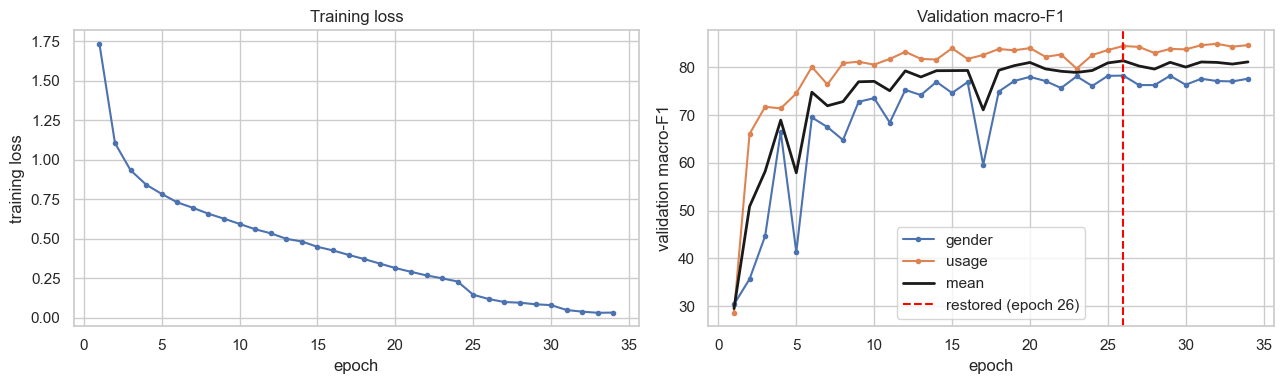

In [11]:
# ============================================
# CELL 11 - Train the model
# ============================================

print("Training the reference configuration: VGG-style blocks, early branching,")
print("ReLU, max pooling, flatten head.\n")

run("base", lambda: EarlyBranchCNN(NUM_CLASSES))

history = HISTORIES["base"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["epoch"], history["train_loss"], marker=".")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss")
axes[1].plot(history["epoch"], history["val_gender_f1"], marker=".", label="gender")
axes[1].plot(history["epoch"], history["val_usage_f1"], marker=".", label="usage")
axes[1].plot(history["epoch"], history["val_mean_f1"], "k-", lw=2, label="mean")
best_epoch = history.loc[history["val_mean_f1"].idxmax(), "epoch"]
axes[1].axvline(best_epoch, ls="--", color="red", label=f"restored (epoch {int(best_epoch)})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation macro-F1")
axes[1].set_title("Validation macro-F1"); axes[1].legend()
plt.tight_layout(); plt.show()

## Part 5 — Class imbalance

`usage` is 77% `Casual`. In a batch of 128 images drawn at random, roughly 99 are Casual and 7
are Formal, so the network sees the majority class an order of magnitude more often.

The first step is to establish the mechanism by which the imbalance harms performance, because
the symptom is easily misdiagnosed. If the network were labelling everything `Casual`, that class
would be substantially over-predicted and its precision would be low. Cell 12 tests this before
any correction is applied.

Two corrections are then evaluated:

1. **Balanced batch sampling** — construct each batch with equal numbers of each class, drawn
   fresh from the full pool. This has the same effect as duplicating minority rows, without
   repeating fixed copies that the network can memorise.
2. **Balanced sampling with mild augmentation** — adding horizontal flips and small
   scale/translation jitter. Rotation is deliberately excluded: the evaluation images are
   upright catalogue photographs, so training on tilted garments would spend capacity on a
   situation that never occurs.

Both alter how the network is trained rather than how its outputs are interpreted.

Each correction is judged on two quantities: macro-F1, which is the metric the model is selected
on, and the recall of the weakest `usage` class, which is what the correction is intended to
raise. The two need not move together. Because one network predicts both attributes, the
effect of a usage-balanced sampler on the gender head is measured as well — a sampler that
equalises one attribute necessarily unbalances the other, and whether that costs anything is a
question for measurement rather than for the argument.

In [12]:
# ============================================
# CELL 12 - Diagnosing the cost of the imbalance
# ============================================

base_val = predict(MODELS["base"], val_loader)

print(classification_report(base_val["usage"]["true"], base_val["usage"]["pred"],
                            target_names=class_names["usage"], zero_division=0, digits=3))

predicted = Counter(base_val["usage"]["pred"])
actual = Counter(base_val["usage"]["true"])
comparison = pd.DataFrame({
    "class": class_names["usage"],
    "actual": [actual[i] for i in range(NUM_CLASSES["usage"])],
    "predicted": [predicted[i] for i in range(NUM_CLASSES["usage"])],
})
comparison["over-predicted by"] = comparison["predicted"] - comparison["actual"]
display(comparison)

recall = [np.mean(base_val["usage"]["pred"][base_val["usage"]["true"] == i] == i)
          for i in range(NUM_CLASSES["usage"])]
weakest = int(np.argmin(recall))
print(f"weakest class: {class_names['usage'][weakest]}, "
      f"recall {recall[weakest] * 100:.1f}%")
print("Indiscriminate prediction of the majority class would show as a large positive")
print("over-prediction count for Casual together with low precision on that class.")
print("The table above determines whether that is the mechanism at work here.")

              precision    recall  f1-score   support

      Casual      0.935     0.952     0.943      4231
      Ethnic      0.917     0.899     0.908       367
      Formal      0.842     0.766     0.802       342
      Sports      0.751     0.700     0.725       560

    accuracy                          0.911      5500
   macro avg      0.861     0.829     0.844      5500
weighted avg      0.909     0.911     0.910      5500



,class,actual,predicted,over-predicted by
0,Casual,4231,4307,76
1,Ethnic,367,360,-7
2,Formal,342,311,-31
3,Sports,560,522,-38


weakest class: Sports, recall 70.0%
Indiscriminate prediction of the majority class would show as a large positive
over-prediction count for Casual together with low precision on that class.
The table above determines whether that is the mechanism at work here.


In [13]:
# ============================================
# CELL 13 - Balanced batch sampling
# ============================================

class BalancedBatchSampler(Sampler):
    """Each batch holds an equal number of every class, sampled with replacement
    from the full pool so minority items are not repeated in fixed combinations."""

    def __init__(self, labels, batch_size=128, batches_per_epoch=None, seed=RANDOM_STATE):
        self.labels = np.asarray(labels)
        self.classes = np.unique(self.labels)
        self.per_class = max(1, batch_size // len(self.classes))
        self.batch_size = self.per_class * len(self.classes)
        self.by_class = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.batches_per_epoch = batches_per_epoch or (len(self.labels) // self.batch_size)
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            for cls in self.classes:
                pool = self.by_class[cls]
                batch.extend(self.rng.choice(pool, self.per_class,
                                             replace=len(pool) < self.per_class))
            self.rng.shuffle(batch)
            yield [int(i) for i in batch]


sampler = BalancedBatchSampler(train_df["usage_y"].to_numpy(), CONFIG["batch_size"])
print(f"batch composition: {sampler.per_class} per class x "
      f"{len(sampler.classes)} classes = {sampler.batch_size} images")
print(f"batches per epoch: {len(sampler)}")

natural = train_df["usage_y"].value_counts(normalize=True).sort_index()
print("\nusage share per batch, before and after balancing:")
display(pd.DataFrame({
    "class": class_names["usage"],
    "natural %": (natural.values * 100).round(1),
    "balanced %": [round(100 / len(sampler.classes), 1)] * len(sampler.classes)}))

balanced_loader = make_loader(train_df, batch_sampler=sampler)
run("balanced", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=balanced_loader)

batch composition: 32 per class x 4 classes = 128 images
batches per epoch: 214

usage share per batch, before and after balancing:


,class,natural %,balanced %
0,Casual,77.1,25.0
1,Ethnic,6.7,25.0
2,Formal,5.9,25.0
3,Sports,10.2,25.0


  [balanced] epoch  1/50 loss 1.6159 val mean macro-F1 43.48  best
  [balanced] epoch  2/50 loss 0.8879 val mean macro-F1 58.19  best
  [balanced] epoch  3/50 loss 0.7687 val mean macro-F1 61.41  best
  [balanced] epoch  5/50 loss 0.5975 val mean macro-F1 68.26  best
  [balanced] epoch  7/50 loss 0.4908 val mean macro-F1 71.83  best
  [balanced] epoch  8/50 loss 0.4592 val mean macro-F1 73.39  best
  [balanced] epoch 10/50 loss 0.4007 val mean macro-F1 69.36
  [balanced] epoch 12/50 loss 0.3322 val mean macro-F1 74.73  best
  [balanced] epoch 14/50 loss 0.2976 val mean macro-F1 75.74  best
  [balanced] epoch 15/50 loss 0.2808 val mean macro-F1 76.75  best
  [balanced] epoch 16/50 loss 0.2560 val mean macro-F1 77.66  best
  [balanced] epoch 17/50 loss 0.2451 val mean macro-F1 77.80  best
  [balanced] epoch 19/50 loss 0.2144 val mean macro-F1 78.40  best
  [balanced] epoch 20/50 loss 0.1936 val mean macro-F1 76.69
  [balanced] epoch 22/50 loss 0.1785 val mean macro-F1 80.54  best
  [bala

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

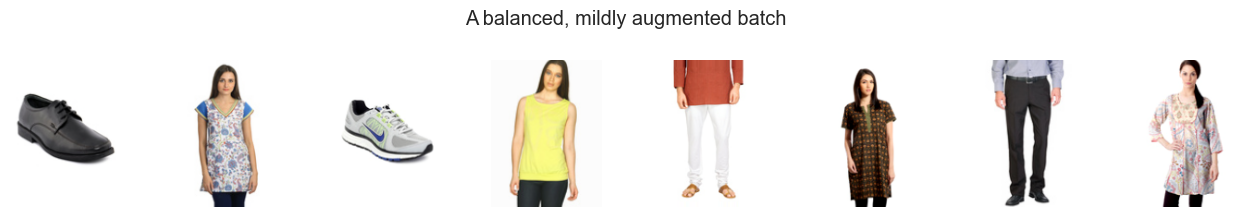

  [balanced_aug] epoch  1/50 loss 1.7007 val mean macro-F1 38.65  best
  [balanced_aug] epoch  2/50 loss 1.0367 val mean macro-F1 49.79  best
  [balanced_aug] epoch  4/50 loss 0.8501 val mean macro-F1 59.73  best
  [balanced_aug] epoch  5/50 loss 0.7789 val mean macro-F1 60.61  best
  [balanced_aug] epoch  7/50 loss 0.6814 val mean macro-F1 65.17  best
  [balanced_aug] epoch  8/50 loss 0.6492 val mean macro-F1 66.75  best
  [balanced_aug] epoch  9/50 loss 0.6185 val mean macro-F1 69.05  best
  [balanced_aug] epoch 10/50 loss 0.5915 val mean macro-F1 67.24
  [balanced_aug] epoch 11/50 loss 0.5731 val mean macro-F1 71.06  best
  [balanced_aug] epoch 15/50 loss 0.4805 val mean macro-F1 68.50
  [balanced_aug] epoch 16/50 loss 0.4223 val mean macro-F1 72.98  best
  [balanced_aug] epoch 17/50 loss 0.4035 val mean macro-F1 73.89  best
  [balanced_aug] epoch 18/50 loss 0.3926 val mean macro-F1 75.17  best
  [balanced_aug] epoch 20/50 loss 0.3653 val mean macro-F1 74.86
  [balanced_aug] epoch 2

EarlyBranchCNN(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (branches): Mod

In [14]:
# ============================================
# CELL 14 - Balanced sampling with mild augmentation
# ============================================

def gentle_augment(tensor):
    """Horizontal flip, small scale and translation, mild brightness.

    No rotation: the evaluation images are upright, so tilted training examples
    would not resemble anything the model is asked to classify.
    """
    if torch.rand(1).item() < 0.5:
        tensor = torch.flip(tensor, dims=[2])

    scale = 1.0 + (torch.rand(1).item() * 2 - 1) * 0.10
    shift_x = (torch.rand(1).item() * 2 - 1) * 0.05
    shift_y = (torch.rand(1).item() * 2 - 1) * 0.05
    theta = torch.tensor([[1 / scale, 0.0, shift_x],
                          [0.0, 1 / scale, shift_y]], dtype=torch.float32).unsqueeze(0)
    grid = F.affine_grid(theta, (1,) + tuple(tensor.shape), align_corners=False)
    tensor = F.grid_sample(tensor.unsqueeze(0), grid, align_corners=False,
                           padding_mode="border").squeeze(0)

    tensor = tensor * (1.0 + (torch.rand(1).item() * 2 - 1) * 0.10)
    return tensor


augmented_loader = make_loader(
    train_df,
    batch_sampler=BalancedBatchSampler(train_df["usage_y"].to_numpy(),
                                       CONFIG["batch_size"], seed=RANDOM_STATE + 1),
    transform=gentle_augment)

# what the augmentation actually does
sample_images, _, _ = next(iter(augmented_loader))
denorm = (sample_images[:8] * STD_T + MEAN_T).permute(0, 2, 3, 1).numpy()
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, image in zip(axes, denorm):
    ax.imshow(np.clip(image, 0, 1)); ax.axis("off")
plt.suptitle("A balanced, mildly augmented batch")
plt.tight_layout(); plt.show()

# Augmentation presents a slightly different image each epoch, so this configuration
# converges more slowly than the other two. The shared cap in CELL 1 is set wide
# enough for it, and early stopping ends the faster runs sooner.
run("balanced_aug", lambda: EarlyBranchCNN(NUM_CLASSES), loader_train=augmented_loader)

,approach,mean macro-F1,usage macro-F1,weakest usage recall,change vs none
0,no correction,81.35,84.45,70.00,0.00
1,balanced sampling,82.82,85.26,70.89,1.47
2,balanced + augmentation,81.79,85.08,83.39,0.44


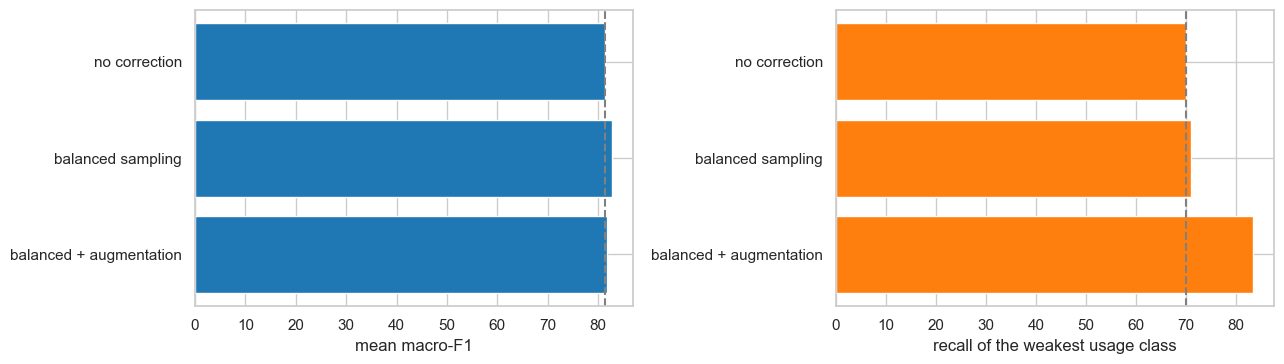

In [15]:
# ============================================
# CELL 15 - Comparison of the two corrections
# ============================================

def weakest_recall(predictions, target="usage"):
    return min(np.mean(predictions[target]["pred"][predictions[target]["true"] == i] == i)
               for i in range(NUM_CLASSES[target])) * 100


rows = [{"approach": "no correction", "mean macro-F1": RESULTS["base"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["base"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(base_val)},
        {"approach": "balanced sampling", "mean macro-F1": RESULTS["balanced"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["balanced"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(predict(MODELS["balanced"], val_loader))},
        {"approach": "balanced + augmentation",
         "mean macro-F1": RESULTS["balanced_aug"]["mean_macro_f1"],
         "usage macro-F1": RESULTS["balanced_aug"]["usage"]["macro_f1"],
         "weakest usage recall": weakest_recall(predict(MODELS["balanced_aug"], val_loader))}]

imbalance = pd.DataFrame(rows).round(2)
imbalance["change vs none"] = (imbalance["mean macro-F1"]
                               - imbalance["mean macro-F1"].iloc[0]).round(2)
display(imbalance)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(imbalance["approach"], imbalance["mean macro-F1"], color="tab:blue")
axes[0].axvline(imbalance["mean macro-F1"].iloc[0], ls="--", color="grey")
axes[0].set_xlabel("mean macro-F1"); axes[0].invert_yaxis()
axes[1].barh(imbalance["approach"], imbalance["weakest usage recall"], color="tab:orange")
axes[1].axvline(imbalance["weakest usage recall"].iloc[0], ls="--", color="grey")
axes[1].set_xlabel("recall of the weakest usage class"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

imbalance.to_csv(ARTIFACT_DIR / "imbalance_comparison.csv", index=False)

,approach,gender macro-F1,usage macro-F1,gender change,usage change
0,no correction,78.25,84.45,0.00,0.00
1,balanced sampling,80.37,85.26,2.12,0.81
2,balanced + augmentation,78.49,85.08,0.24,0.63


Gender composition of each usage class in the training split (%):


gender_label,Boys,Girls,Men,Unisex,Women
usage_label,,,,,
Casual,2.6,2.0,53.2,6.1,36.1
Ethnic,0.4,0.3,3.9,0.0,95.5
Formal,0.0,0.0,94.9,0.1,5.0
Sports,0.5,0.0,73.1,7.5,18.9


,natural %,balanced batches %,ratio
gender_label,,,
Boys,2.1,0.9,0.43
Girls,1.6,0.6,0.37
Men,54.4,56.3,1.03
Unisex,5.5,3.4,0.62
Women,36.5,38.9,1.07


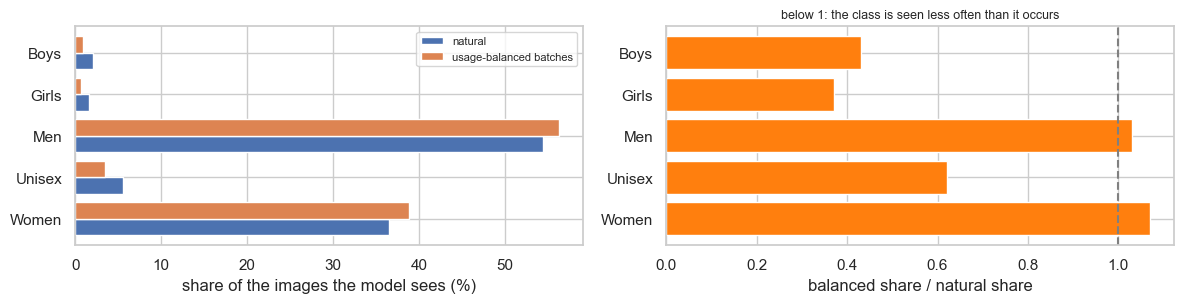

Balanced sampling changed usage macro-F1 by +0.81 and gender macro-F1 by +2.12.

The minority usage classes are dominated by the majority genders (Ethnic is 95% Women, Formal is 95% Men),
so drawing them equally makes the rare gender classes rarer still: Girls falls from 1.6%
to 0.6% of the images the model sees, a factor of 0.37.
Gender macro-F1 weights all five classes equally, so a thinner exposure to the rare
genders is where a cost would show. On this run it did not show: gender macro-F1 moved
+2.12. The distortion in the batches is real and measured above; the loss it
predicts is not present in the result.

Every configuration here is a single run. Part 6 states the margin below which
a difference between two of them is not evidence.


In [25]:
# ============================================
# CELL 16 - The effect of the sampler on the other attribute
# ============================================

# The sampler equalises the four usage classes. Gender and usage are not
# independent, so changing one distribution changes the other. This cell measures
# what the gender head is trained on once the sampler is in place.

attribute_cost = pd.DataFrame([
    {"approach": label,
     "gender macro-F1": round(RESULTS[tag]["gender"]["macro_f1"], 2),
     "usage macro-F1": round(RESULTS[tag]["usage"]["macro_f1"], 2)}
    for label, tag in [("no correction", "base"),
                       ("balanced sampling", "balanced"),
                       ("balanced + augmentation", "balanced_aug")]])
for column in ["gender macro-F1", "usage macro-F1"]:
    attribute_cost[column.replace("macro-F1", "change")] = (
        attribute_cost[column] - attribute_cost[column].iloc[0]).round(2)
display(attribute_cost)

# The composition of each usage class is what the sampler re-weights.
mix = pd.crosstab(train_df["usage_label"], train_df["gender_label"],
                  normalize="index") * 100
print("Gender composition of each usage class in the training split (%):")
display(mix.round(1))

# With equal numbers of every usage class in each batch, the gender distribution
# the model sees becomes the unweighted mean of the rows above, not the true one.
natural = train_df["gender_label"].value_counts(normalize=True).sort_index() * 100
exposure = pd.DataFrame({"natural %": natural.round(1),
                         "balanced batches %": mix.mean(axis=0).round(1)})
exposure["ratio"] = (exposure["balanced batches %"] / exposure["natural %"]).round(2)
display(exposure)

offset = np.arange(len(exposure))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
axes[0].barh(offset + 0.2, exposure["natural %"], height=0.4, label="natural")
axes[0].barh(offset - 0.2, exposure["balanced batches %"], height=0.4,
             label="usage-balanced batches")
axes[0].set_xlabel("share of the images the model sees (%)")
axes[0].legend(fontsize=8)

axes[1].barh(offset, exposure["ratio"], color="tab:orange")
axes[1].axvline(1.0, ls="--", color="grey")
axes[1].set_xlabel("balanced share / natural share")
axes[1].set_title("below 1: the class is seen less often than it occurs", fontsize=9)

for ax in axes:
    ax.set_yticks(offset); ax.set_yticklabels(exposure.index); ax.invert_yaxis()
plt.tight_layout(); plt.show()

dominant = mix.idxmax(axis=1)
skewed = ", ".join(f"{usage} is {mix.loc[usage, dominant[usage]]:.0f}% {dominant[usage]}"
                   for usage in mix.index if mix.loc[usage, dominant[usage]] > 80)
starved = exposure["ratio"].idxmin()

print(f"Balanced sampling changed usage macro-F1 by "
      f"{attribute_cost.loc[1, 'usage change']:+.2f} and gender macro-F1 by "
      f"{attribute_cost.loc[1, 'gender change']:+.2f}.")
print(f"\nThe minority usage classes are dominated by the majority genders ({skewed}),")
print(f"so drawing them equally makes the rare gender classes rarer still: {starved} falls "
      f"from {exposure.loc[starved, 'natural %']:.1f}%")
print(f"to {exposure.loc[starved, 'balanced batches %']:.1f}% of the images the model sees, "
      f"a factor of {exposure.loc[starved, 'ratio']:.2f}.")
# The exposure table above establishes a mechanism by which the sampler *could* cost
# gender accuracy. Whether it did is a separate question, settled by measurement rather
# than by the mechanism, and the answer is not fixed in advance.
gender_change = attribute_cost.loc[1, "gender change"]
if gender_change < 0:
    print("Gender macro-F1 weights all five classes equally, and that is where the cost "
          f"appears:\ngender macro-F1 moved {gender_change:+.2f}.")
else:
    print("Gender macro-F1 weights all five classes equally, so a thinner exposure to the "
          "rare\ngenders is where a cost would show. On this run it did not show: gender "
          f"macro-F1 moved\n{gender_change:+.2f}. The distortion in the batches is real and "
          "measured above; the loss it\npredicts is not present in the result.")
print("\nEvery configuration here is a single run. Part 6 states the margin below which\n"
      "a difference between two of them is not evidence.")

exposure.to_csv(ARTIFACT_DIR / "sampler_gender_exposure.csv")


## Part 6 — Model selection and test results

Selection is performed on the validation partition alone. The test partition is held out until
the model is fixed, and is evaluated exactly once.

Two quantities bound how precisely two configurations can be compared. The first is the sampling
error of the validation set, which reflects its finite size. The second is the variation between
independent training runs of the same configuration, which arises from the random initialisation,
the ordering of batches, and non-deterministic GPU kernels. A difference smaller than either
quantity is not evidence of a difference in the configurations.

Every criterion in the selection rule is judged against that same threshold, including the
tie-break: a difference too small to separate two configurations on the primary metric cannot
decide between them on a secondary one either. Where nothing separates the candidates, the
configuration requiring the least machinery is retained.

### Run-to-run variability

A configuration's score moves between runs of identical code: the weights are initialised
randomly, the batch ordering differs, and several GPU kernels are non-deterministic. One run
therefore cannot establish on its own that one configuration is better than another.

Each configuration here is trained once, under a common seed and a common epoch cap. That buys
speed at the cost of being unable to measure the training variance from this experiment, so the
figure is carried over instead: repeating this notebook under three seeds at the earlier 60×80
resolution put the largest per-configuration standard deviation at 1.17 macro-F1. It is used as a
floor on the threshold rather than as a measurement, and it is reported as carried over wherever
it appears. Dropping it would leave the sampling error alone to decide the ranking, which is
precisely the error this section exists to prevent.

The larger of the two uncertainties — sampling error and training variance — is the threshold
below which two configurations are treated as indistinguishable.


In [17]:
# ============================================
# CELL 17 - Collecting the trained configurations
# ============================================

# One seed per configuration. All three were trained in Parts 4 and 5, so this cell
# retrains nothing; it collects them into one frame for the comparison below. Adding
# further seeds to this list is the only change needed to restore repeated runs, and
# everything downstream — the spread, the threshold, the plots — adapts to the count.
SEEDS = [RANDOM_STATE]


def build_base():
    return EarlyBranchCNN(NUM_CLASSES)


def loader_for(name, seed):
    """The training loader a configuration needs; None means the default loader."""
    if name == "balanced":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed))
    if name == "balanced_aug":
        return make_loader(train_df, batch_sampler=BalancedBatchSampler(
            train_df["usage_y"].to_numpy(), CONFIG["batch_size"], seed=seed + 1),
            transform=gentle_augment)
    return None


repeat_rows, seed_models = [], {}

for name in ["base", "balanced", "balanced_aug"]:
    for seed in SEEDS:
        tag = f"{name}-s{seed}"
        if seed == SEEDS[0] and name in RESULTS:       # already trained in Part 5
            summary, model = RESULTS[name], MODELS[name]
        else:
            set_seed(seed)
            model, _ = train_model(build_base(), tag,
                                   loader_train=loader_for(name, seed), verbose=False)
            summary = summarise(predict(model, val_loader))
        seed_models[(name, seed)] = model
        repeat_rows.append({
            "configuration": name, "seed": seed,
            "mean macro-F1": round(summary["mean_macro_f1"], 2),
            "usage macro-F1": round(summary["usage"]["macro_f1"], 2),
            "gender macro-F1": round(summary["gender"]["macro_f1"], 2),
            "exact match": round(summary["exact_match"], 2)})
        print(f"  {name:9s} seed {seed:>4} -> mean {repeat_rows[-1]['mean macro-F1']:6.2f} | "
              f"usage {repeat_rows[-1]['usage macro-F1']:6.2f} | "
              f"gender {repeat_rows[-1]['gender macro-F1']:6.2f}")

repeats = pd.DataFrame(repeat_rows)
display(repeats)

  base      seed   42 -> mean  81.35 | usage  84.45 | gender  78.25
  balanced  seed   42 -> mean  82.82 | usage  85.26 | gender  80.37
  balanced_aug seed   42 -> mean  81.79 | usage  85.08 | gender  78.49


,configuration,seed,mean macro-F1,usage macro-F1,gender macro-F1,exact match
0,base,42,81.35,84.45,78.25,82.58
1,balanced,42,82.82,85.26,80.37,82.98
2,balanced_aug,42,81.79,85.08,78.49,81.04


,runs,mean,sd,usage_mean,usage_sd,exact_mean
configuration,,,,,,
balanced,1,82.82,NaN,85.26,NaN,82.98
balanced_aug,1,81.79,NaN,85.08,NaN,81.04
base,1,81.35,NaN,84.45,NaN,82.58


sampling error of the validation set    : +-0.67
training variance (carried over from the 60x80 three-seed run): +-1.17
threshold for a meaningful difference   : +-1.17



,mean macro-F1,vs leader,usage macro-F1,usage vs leader,within threshold
configuration,,,,,
balanced,82.82,0.00,85.26,0.00,True
balanced_aug,81.79,-1.03,85.08,-0.18,True
base,81.35,-1.47,84.45,-0.81,False


leading configuration: balanced

  balanced_aug   indistinguishable from the leader on the mean (-1.03);
                 usage macro-F1 -0.18 against the leader
  base           below the leader by more than the threshold (-1.47);
                 usage macro-F1 -0.81 against the leader

Within the threshold of the leader: ['balanced', 'balanced_aug'].
Selection in the next cell ranks on this table and breaks remaining ties on
usage macro-F1, the attribute the corrections in Part 5 were intended to improve.


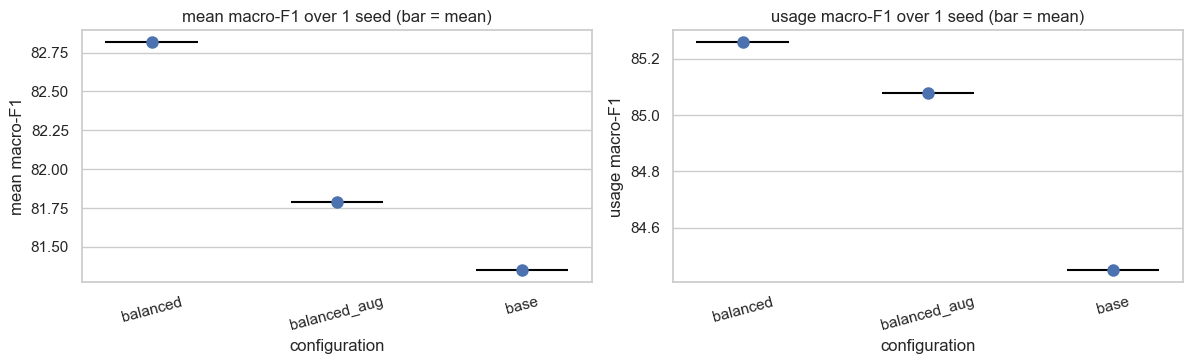

In [18]:
# ============================================
# CELL 18 - Decomposing the uncertainty
# ============================================

stats = repeats.groupby("configuration").agg(
    runs=("mean macro-F1", "size"),
    mean=("mean macro-F1", "mean"), sd=("mean macro-F1", "std"),
    usage_mean=("usage macro-F1", "mean"), usage_sd=("usage macro-F1", "std"),
    exact_mean=("exact match", "mean")).round(2)
display(stats)

# Sampling error of a proportion estimated on the validation set: the uncertainty
# attributable to its finite size alone.
NOISE_FLOOR = 100 * np.sqrt(0.5 * 0.5 / len(val_df))

# Training variance. A single run per configuration leaves nothing to take a standard
# deviation over, so the figure is carried over from the three-seed repeat of this
# notebook at 60x80, where the largest per-configuration standard deviation was 1.17.
# It is a prior, not a measurement, and is labelled as such wherever it is printed.
# Adding seeds to SEEDS replaces it with the value measured here.
PRIOR_SEED_SD = 1.17
measured = repeats.groupby("configuration")["mean macro-F1"].std().max()
if np.isfinite(measured):
    spread, SPREAD_SOURCE = float(measured), "measured across seeds"
else:
    spread, SPREAD_SOURCE = PRIOR_SEED_SD, "carried over from the 60x80 three-seed run"
EFFECTIVE_NOISE = max(NOISE_FLOOR, spread)

print(f"sampling error of the validation set    : +-{NOISE_FLOOR:.2f}")
print(f"training variance ({SPREAD_SOURCE}): +-{spread:.2f}")
print(f"threshold for a meaningful difference   : +-{EFFECTIVE_NOISE:.2f}\n")

leader = stats["mean"].idxmax()
gaps = pd.DataFrame({
    "mean macro-F1": stats["mean"],
    "vs leader": (stats["mean"] - stats.loc[leader, "mean"]).round(2),
    "usage macro-F1": stats["usage_mean"],
    "usage vs leader": (stats["usage_mean"] - stats.loc[leader, "usage_mean"]).round(2),
}).sort_values("mean macro-F1", ascending=False)
gaps["within threshold"] = (stats.loc[leader, "mean"] - gaps["mean macro-F1"]) < EFFECTIVE_NOISE
display(gaps)

print(f"leading configuration: {leader}\n")
for name in gaps.index:
    if name == leader:
        continue
    difference, usage_difference = gaps.loc[name, ["vs leader", "usage vs leader"]]
    if abs(difference) < EFFECTIVE_NOISE:
        verdict = "indistinguishable from the leader on the mean"
    else:
        verdict = "below the leader by more than the threshold"
    print(f"  {name:14s} {verdict} ({difference:+.2f});")
    print(f"  {'':14s} usage macro-F1 {usage_difference:+.2f} against the leader")

tied = list(gaps.index[gaps["within threshold"]])
print(f"\nWithin the threshold of the leader: {tied}.")
print("Selection in the next cell ranks on this table and breaks remaining ties on")
print("usage macro-F1, the attribute the corrections in Part 5 were intended to improve.")

# The order is stated explicitly so that each mean bar lands on its own column:
# seaborn orders categories by first appearance, which is not the order of `stats`.
ORDER = list(gaps.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, column, key in [(axes[0], "mean macro-F1", "mean"),
                        (axes[1], "usage macro-F1", "usage_mean")]:
    sns.stripplot(data=repeats, x="configuration", y=column, ax=ax, size=9, order=ORDER)
    for position, name in enumerate(ORDER):
        ax.hlines(stats.loc[name, key], position - 0.25, position + 0.25, color="black")
    ax.set_title(f"{column} over {len(SEEDS)} seed"
                 f"{'s' if len(SEEDS) > 1 else ''} (bar = mean)")
    ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout(); plt.show()

repeats.to_csv(ARTIFACT_DIR / "seed_repeats.csv", index=False)


In [26]:
# ============================================
# CELL 19 - Selection
# ============================================

# Selection rule, fixed before the scores are examined and applied in order:
#   1. rank on mean macro-F1;
#   2. treat every configuration within EFFECTIVE_NOISE of the leader as tied;
#   3. among tied configurations, prefer the one with the higher usage macro-F1,
#      since usage is the attribute the corrections in Part 5 were intended to
#      improve, but only where that advantage itself exceeds EFFECTIVE_NOISE;
#   4. otherwise prefer the simpler pipeline, and then the smaller model.
# All three configurations are trained under the same epoch cap and the same seed, so
# the ranking compares like with like. With one run each, the threshold is doing more
# work than usual: it is the only thing standing between the ranking and the run-to-run
# noise, and its training-variance term is carried over rather than measured here.
#
# Step 3 originally carried no threshold of its own. Applied that way it selected a
# configuration whose usage advantage was smaller than EFFECTIVE_NOISE, which is a
# margin this notebook treats as indistinguishable everywhere else. A criterion
# cannot decide on a difference it has already classified as noise, so the same
# threshold now governs both steps, and step 4 falls through to the configuration
# that requires the least machinery: the standard loader ahead of a custom sampler,
# and a custom sampler ahead of one combined with augmentation.

print(f"validation set: {len(val_df):,} images")
print(f"sampling error       +-{NOISE_FLOOR:.2f}   "
      f"training variance +-{spread:.2f}   "
      f"threshold +-{EFFECTIVE_NOISE:.2f}\n")

averaged = repeats.groupby("configuration")[["mean macro-F1", "usage macro-F1",
                                             "exact match"]].mean()


def score(tag, column, fallback):
    """Seed-averaged score where repeats exist, otherwise the single run."""
    if tag in averaged.index:
        return round(float(averaged.loc[tag, column]), 2)
    return round(fallback, 2)


candidates = ["base", "balanced", "balanced_aug"]
selection = pd.DataFrame([
    {"model": tag,
     "runs": int((repeats["configuration"] == tag).sum()) or 1,
     "mean macro-F1": score(tag, "mean macro-F1", RESULTS[tag]["mean_macro_f1"]),
     "usage macro-F1": score(tag, "usage macro-F1", RESULTS[tag]["usage"]["macro_f1"]),
     "exact match": score(tag, "exact match", RESULTS[tag]["exact_match"]),
     "parameters": count_parameters(MODELS[tag])}
    for tag in candidates]).sort_values("mean macro-F1", ascending=False)
display(selection)

# Steps 1 and 2.
leader = selection.iloc[0]["model"]
best_score = selection.iloc[0]["mean macro-F1"]
tied = selection[selection["mean macro-F1"] >= best_score - EFFECTIVE_NOISE]

# Step 3, applied only where the tie-break margin clears the same threshold.
leader_usage = float(selection.loc[selection["model"] == leader,
                                   "usage macro-F1"].iloc[0])
decisive = tied[tied["usage macro-F1"] - leader_usage > EFFECTIVE_NOISE]

# Step 4: least machinery first, then fewest parameters.
COMPLEXITY = {"base": 0, "balanced": 1, "balanced_aug": 2}

if len(decisive):
    FINAL_NAME = decisive.sort_values("usage macro-F1",
                                      ascending=False).iloc[0]["model"]
    SELECTION_REASON = "usage macro-F1 is ahead by more than the threshold"
else:
    FINAL_NAME = (tied.assign(complexity=tied["model"].map(COMPLEXITY))
                  .sort_values(["complexity", "parameters"]).iloc[0]["model"])
    SELECTION_REASON = ("no criterion separates the tied configurations by more "
                        "than the threshold,\nso the simplest pipeline is retained")

# Among the seeds trained for the selected configuration, retain the strongest.
seed_scores = repeats[repeats["configuration"] == FINAL_NAME]
if len(seed_scores):
    BEST_SEED = int(seed_scores.sort_values("mean macro-F1",
                                            ascending=False).iloc[0]["seed"])
    FINAL_MODEL = seed_models[(FINAL_NAME, BEST_SEED)]
else:
    BEST_SEED = RANDOM_STATE
    FINAL_MODEL = MODELS[FINAL_NAME]

print(f"within +-{EFFECTIVE_NOISE:.2f} of the leader: {list(tied['model'])}")
if len(tied) > 1:
    print(SELECTION_REASON)
else:
    print("no tie: the leading configuration is ahead by more than the threshold")

print(f"\nselected: {FINAL_NAME}, seed {BEST_SEED}, "
      f"{count_parameters(FINAL_MODEL):,} parameters")

# Which configuration survives this rule is not fixed in advance. If the uncorrected
# pipeline is retained, the corrections stay in the notebook because the diagnosis and
# the negative result are themselves the finding. If a correction is retained instead,
# the qualifier that matters is the budget: both sampler configurations reach their best
# epoch close to the cap while the uncorrected run converges and stops early, so the
# truncation works against the winner rather than for it.
if FINAL_NAME == "base":
    print("\nNeither imbalance correction was retained; see Cell 15 for the trade-off "
          "each produced.")
else:
    print(f"\n{FINAL_NAME} is retained over the uncorrected pipeline; Cell 15 gives the "
          "trade-off it\nproduced. It reached its best epoch near the cap, so its score "
          "is a floor rather than\na peak, and the margin over the uncorrected run is "
          f"{best_score - float(selection.loc[selection['model'] == 'base', 'mean macro-F1'].iloc[0]):.2f} "
          f"against a threshold of {EFFECTIVE_NOISE:.2f}.")

validation set: 5,500 images
sampling error       +-0.67   training variance +-1.17   threshold +-1.17



,model,runs,mean macro-F1,usage macro-F1,exact match,parameters
1,balanced,1,82.82,85.26,82.98,13297641
2,balanced_aug,1,81.79,85.08,81.04,13297641
0,base,1,81.35,84.45,82.58,13297641


within +-1.17 of the leader: ['balanced', 'balanced_aug']
no criterion separates the tied configurations by more than the threshold,
so the simplest pipeline is retained

selected: balanced, seed 42, 13,297,641 parameters

balanced is retained over the uncorrected pipeline; Cell 15 gives the trade-off it
produced. It reached its best epoch near the cap, so its score is a floor rather than
a peak, and the margin over the uncorrected run is 1.47 against a threshold of 1.17.


,target,accuracy,macro-F1,balanced accuracy,majority baseline,gain
0,gender,90.07,77.19,77.84,54.20,35.88
1,usage,91.02,84.10,83.80,77.11,13.91


exact match (both attributes correct): 82.00%

GENDER
              precision    recall  f1-score   support

        Boys      0.703     0.847     0.769        98
       Girls      0.690     0.670     0.680       103
         Men      0.924     0.941     0.932      2965
      Unisex      0.607     0.531     0.566       262
       Women      0.922     0.904     0.913      2073

    accuracy                          0.901      5501
   macro avg      0.769     0.778     0.772      5501
weighted avg      0.900     0.901     0.900      5501


USAGE
              precision    recall  f1-score   support

      Casual      0.936     0.949     0.942      4252
      Ethnic      0.815     0.888     0.850       347
      Formal      0.833     0.843     0.838       337
      Sports      0.809     0.673     0.734       565

    accuracy                          0.910      5501
   macro avg      0.848     0.838     0.841      5501
weighted avg      0.909     0.910     0.909      5501



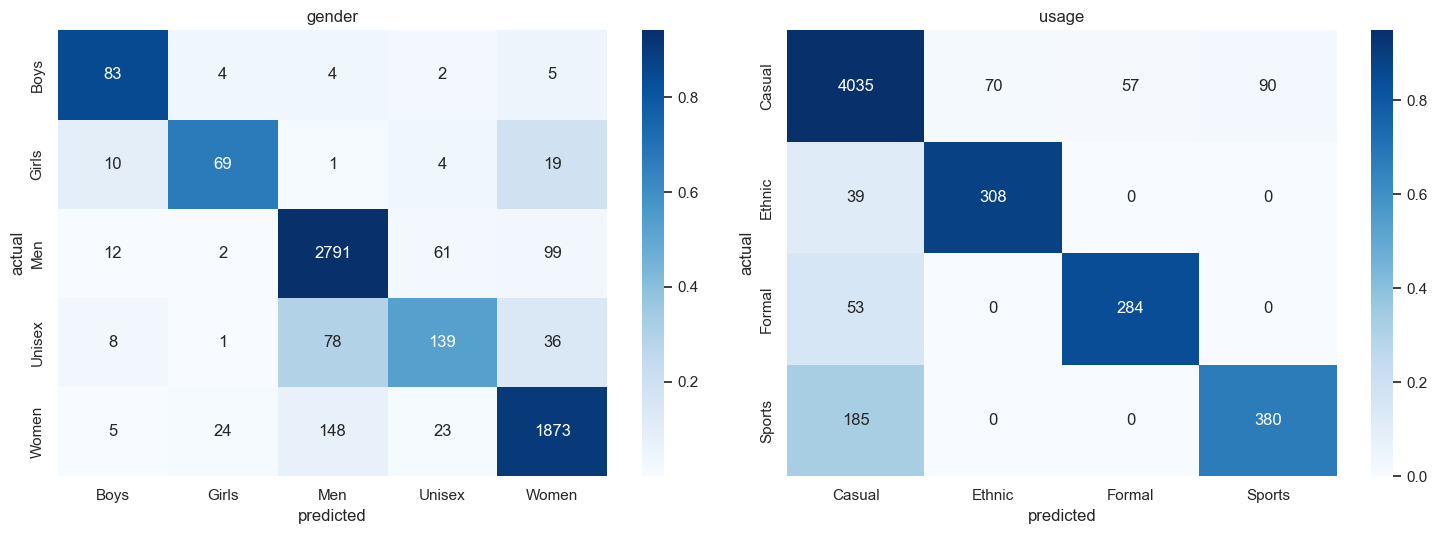

In [20]:
# ============================================
# CELL 20 - Test results
# ============================================

test_predictions = predict(FINAL_MODEL, test_loader)
test_summary = summarise(test_predictions)

final = pd.DataFrame([
    {"target": target,
     "accuracy": round(test_summary[target]["accuracy"], 2),
     "macro-F1": round(test_summary[target]["macro_f1"], 2),
     "balanced accuracy": round(test_summary[target]["balanced_acc"], 2),
     "majority baseline": round(BASELINE[target]["accuracy"], 2),
     "gain": round(test_summary[target]["accuracy"] - BASELINE[target]["accuracy"], 2)}
    for target in CONFIG["targets"]])
display(final)
print(f"exact match (both attributes correct): {test_summary['exact_match']:.2f}%")

for target in CONFIG["targets"]:
    print("\n" + "=" * 58); print(target.upper()); print("=" * 58)
    print(classification_report(test_predictions[target]["true"],
                                test_predictions[target]["pred"],
                                target_names=class_names[target],
                                zero_division=0, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, target in zip(axes, CONFIG["targets"]):
    matrix = confusion_matrix(test_predictions[target]["true"],
                              test_predictions[target]["pred"])
    normalised = matrix / matrix.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(normalised, annot=matrix, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names[target], yticklabels=class_names[target])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(target)
plt.tight_layout(); plt.show()

,items,gender %,usage %
masterCategory,,,
Sporting Goods,3,33.3,33.3
Personal Care,135,79.3,100.0
Accessories,1420,85.2,90.3
Footwear,1219,86.5,90.5
Apparel,2713,94.8,91.2
Free Items,11,100.0,100.0


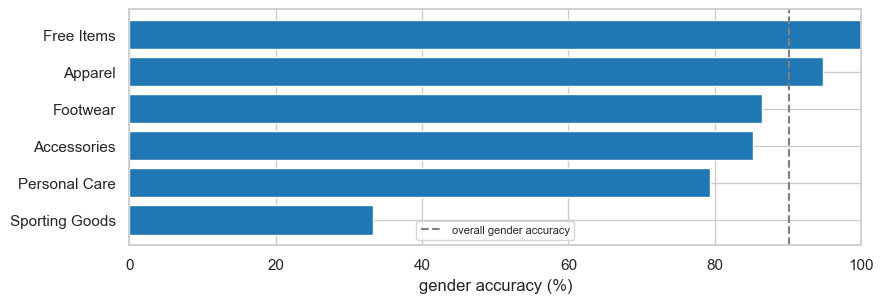

,items,gender %,train examples
group,,,
cosmetics,127,78.0,58
fragrance and other,8,100.0,640


Predicted gender for fragrance, deodorant and gift sets:


gender_pred,Women
gender_label,
Women,8


,share of gender errors %
masterCategory,
Accessories,38.5
Footwear,30.0
Apparel,26.0
Personal Care,5.1
Sporting Goods,0.4


Gender accuracy ranges from 79.3% on Personal Care to 94.8% on Apparel.
The largest single source of error is Accessories, at 38.5% of all gender errors
from 1,420 test items. Personal Care has the lowest rate but contributes
only 5.1%, being 135 items of 5,501.

Accuracy tracks how much of the gender signal is carried by shape. A garment's cut differs
between the men's and women's ranges; a bottle, a watch or a bag frequently does not.
Whether 120x160 resolves enough branding to separate those is what this table measures.


In [21]:
# ============================================
# CELL 21 - Where the errors are
# ============================================

# Aggregate accuracy hides which kinds of item the model fails on. Every test
# prediction is joined back to its catalogue category, so the failures can be
# attributed rather than only counted.

analysis = test_df.copy()
for target in CONFIG["targets"]:
    analysis[target + "_pred"] = [class_names[target][i]
                                  for i in test_predictions[target]["pred"]]

gender_hit = analysis["gender_label"] == analysis["gender_pred"]
usage_hit = analysis["usage_label"] == analysis["usage_pred"]

by_category = pd.DataFrame({
    "items": analysis.groupby("masterCategory").size(),
    "gender %": (gender_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
    "usage %": (usage_hit.groupby(analysis["masterCategory"]).mean() * 100).round(1),
}).sort_values("gender %")
display(by_category)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(by_category.index, by_category["gender %"], color="tab:blue")
ax.axvline(test_summary["gender"]["accuracy"], ls="--", color="grey",
           label="overall gender accuracy")
ax.set_xlabel("gender accuracy (%)"); ax.set_xlim(0, 100); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Personal Care contains two visually distinct populations that carry opposite
# gender priors, so it is split rather than reported as one figure.
COSMETICS = {"Lips", "Nails", "Eyes", "Makeup"}
CARE_GROUPS = ["cosmetics", "fragrance and other"]
care = analysis[analysis["masterCategory"] == "Personal Care"].copy()
# A categorical keeps both rows in the table even when the test partition happens to
# contain none of one group, so the counts below always line up with it.
care["group"] = pd.Categorical(
    np.where(care["subCategory"].isin(COSMETICS), *CARE_GROUPS[::-1]),
    categories=CARE_GROUPS)
care_hit = care["gender_label"] == care["gender_pred"]
display(pd.DataFrame({
    "items": care.groupby("group", observed=False).size(),
    "gender %": (care_hit.groupby(care["group"], observed=False).mean() * 100).round(1),
    "train examples": [int((train_df["subCategory"].isin(COSMETICS)).sum()),
                       int(((train_df["masterCategory"] == "Personal Care") &
                            (~train_df["subCategory"].isin(COSMETICS))).sum())]}))

fragrance = care[care["group"] == "fragrance and other"]
print("Predicted gender for fragrance, deodorant and gift sets:")
if len(fragrance):
    display(pd.crosstab(fragrance["gender_label"], fragrance["gender_pred"]))
else:
    print("  none in the test partition")

# Where the gender errors actually are, as a share of all of them.
error_share = (analysis.loc[~gender_hit, "masterCategory"]
               .value_counts(normalize=True) * 100).round(1)
error_share.name = "share of gender errors %"
display(error_share.to_frame())

substantial = by_category[by_category["items"] >= 50]
worst, best = substantial.index[0], substantial.index[-1]
largest = error_share.index[0]
print(f"Gender accuracy ranges from {substantial.loc[worst, 'gender %']:.1f}% on {worst} "
      f"to {substantial.loc[best, 'gender %']:.1f}% on {best}.")
print(f"The largest single source of error is {largest}, at {error_share.iloc[0]:.1f}% of all "
      f"gender errors\nfrom {int(by_category.loc[largest, 'items']):,} test items. "
      f"{worst} has the lowest rate but contributes\nonly {error_share.get(worst, 0.0):.1f}%, "
      f"being {int(by_category.loc[worst, 'items'])} items of {len(analysis):,}.")
print("\nAccuracy tracks how much of the gender signal is carried by shape. A garment's cut "
      "differs\nbetween the men's and women's ranges; a bottle, a watch or a bag frequently does "
      "not.\nWhether 120x160 resolves enough branding to separate those is what this table "
      "measures.")

by_category.to_csv(ARTIFACT_DIR / "error_analysis.csv")


In [22]:
# ============================================
# CELL 22 - Final architecture specification
# ============================================

settings = FINAL_MODEL.settings
shared_shape = flat_features(FINAL_MODEL.shared)[1]
branch_size, branch_shape = flat_features(
    nn.Sequential(FINAL_MODEL.shared, FINAL_MODEL.branches["gender"]))

specification = pd.DataFrame([
    ("Input", f"{CONFIG['channels']} x {CONFIG['image_height']} x {CONFIG['image_width']} RGB"),
    ("Reference design", "VGG-style: paired 3x3 convolutions per block, channels doubling"),
    ("Multi-task structure", "early branching - shared trunk, then one pathway per attribute"),
    ("Convolution kernel", "3 x 3, stride 1, padding 1 (all layers)"),
    ("Filters, shared trunk", " -> ".join(str(w) for w in settings["shared_widths"])),
    ("Filters, each branch", " -> ".join(str(w) for w in settings["branch_widths"])),
    ("Convolutions per block", "2, each followed by batch normalisation"),
    ("Activation", {"relu": "ReLU", "tanh": "tanh", "sigmoid": "sigmoid"}[settings["activation"]]),
    ("Normalisation", "BatchNorm2d after every convolution"),
    ("Pooling", f"{'max' if settings['pooling'] == 'max' else 'average'} pooling, 2 x 2, stride 2"),
    ("Shared trunk output", f"{shared_shape[0]} x {shared_shape[1]} x {shared_shape[2]}"),
    ("Branch output", f"{branch_shape[0]} x {branch_shape[1]} x {branch_shape[2]}"),
    ("Classifier input", "flatten" if settings["head"] == "flatten"
     else "global average pooling"),
    ("Flattened size", f"{branch_size}" if settings["head"] == "flatten"
     else f"{branch_shape[0]} (one value per channel)"),
    ("Classifier", f"Dropout({settings['dropout']}) -> Linear(., {settings['hidden']}) "
     f"-> ReLU -> Dropout({settings['dropout']}) -> Linear({settings['hidden']}, classes)"),
    ("Output", f"gender {NUM_CLASSES['gender']} scores, usage {NUM_CLASSES['usage']} scores; "
     "softmax applied at prediction time"),
    ("Loss", "cross-entropy per attribute, summed with equal weight"),
    ("Optimiser", f"AdamW, lr {CONFIG['learning_rate']}, weight decay {CONFIG['weight_decay']}"),
    ("Learning rate schedule", "halved after 3 epochs without validation improvement"),
    ("Regularisation", f"dropout {settings['dropout']}, weight decay, batch norm, early stopping"),
    ("Class imbalance", {"base": "none applied",
                         "balanced": "balanced batch sampling (equal classes per batch)",
                         "balanced_aug": "balanced sampling with flip, scale and "
                                         "translation jitter"}.get(FINAL_NAME, FINAL_NAME)),
    ("Training seed", f"{BEST_SEED}" + (f" (best of {len(SEEDS)} repeated runs)"
                                        if len(SEEDS) > 1 else " (one run per configuration)")),
    ("Selection rule", f"highest validation mean macro-F1; ties within "
     f"+-{EFFECTIVE_NOISE:.2f} broken on usage macro-F1"),
    ("Total parameters", f"{count_parameters(FINAL_MODEL):,}"),
], columns=["component", "setting"])

pd.set_option("display.max_colwidth", 90)
display(specification)
specification.to_csv(ARTIFACT_DIR / "final_architecture.csv", index=False)

,component,setting
0,Input,3 x 160 x 120 RGB
1,Reference design,"VGG-style: paired 3x3 convolutions per block, channels doubling"
2,Multi-task structure,"early branching - shared trunk, then one pathway per attribute"
3,Convolution kernel,"3 x 3, stride 1, padding 1 (all layers)"
4,"Filters, shared trunk",32 -> 64
5,"Filters, each branch",128 -> 256 -> 512
6,Convolutions per block,"2, each followed by batch normalisation"
7,Activation,ReLU
8,Normalisation,BatchNorm2d after every convolution
9,Pooling,"max pooling, 2 x 2, stride 2"


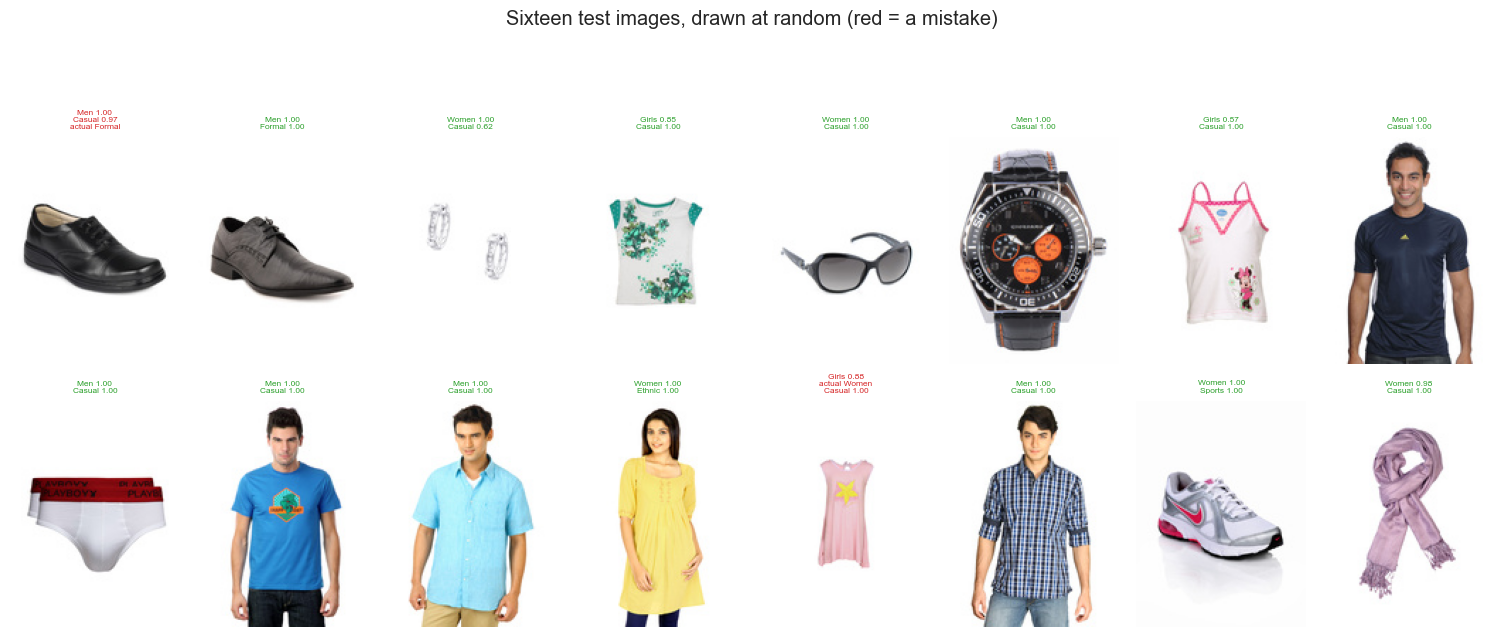

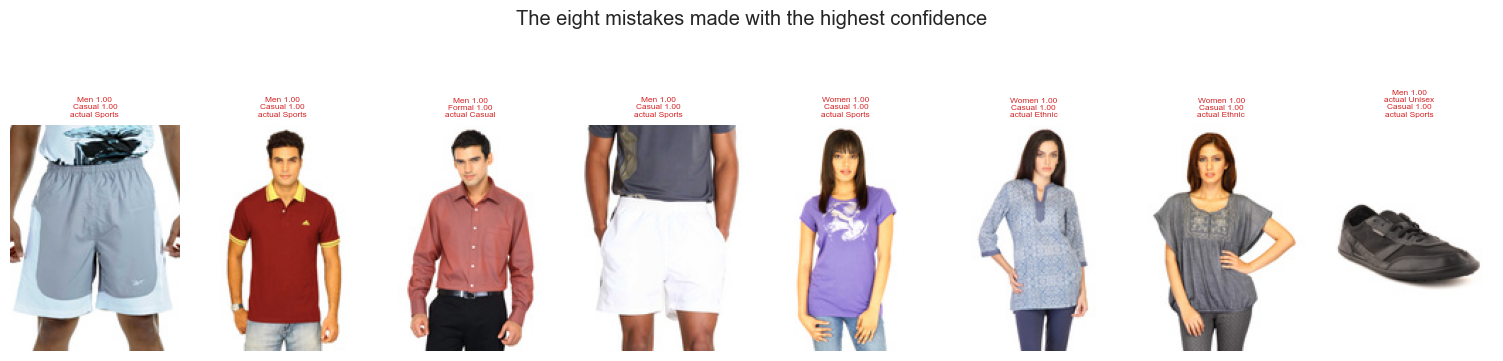

In [23]:
# ============================================
# CELL 23 - Predictions on sample images
# ============================================

# Two panels. A random draw shows typical behaviour; the highest-confidence errors
# show the failure mode. The random draw is sixteen images rather than a handful,
# because at this accuracy a smaller sample is dominated by which items it happened
# to contain.

def prediction_panel(frame, title, columns=8):
    rows = int(np.ceil(len(frame) / columns))
    images, _, _ = next(iter(DataLoader(FashionDataset(frame), batch_size=len(frame))))
    FINAL_MODEL.eval()
    with torch.no_grad():
        logits = FINAL_MODEL(images.to(DEVICE))

    height = 3.0 * rows + 0.8          # reserve space for the figure title
    fig, axes = plt.subplots(rows, columns, figsize=(1.9 * columns, height))
    flat_axes = np.ravel(np.array(axes, dtype=object))
    for position, (ax, (_, row)) in enumerate(zip(flat_axes, frame.iterrows())):
        ax.imshow(np.asarray(IMAGES[row["pos"]])); ax.axis("off")
        lines, correct = [], True
        for target in CONFIG["targets"]:
            probabilities = F.softmax(logits[target][position].float(), dim=0).cpu().numpy()
            index = int(probabilities.argmax())
            hit = class_names[target][index] == row[target + "_label"]
            correct &= hit
            actual = "" if hit else f"\nactual {row[target + '_label']}"
            lines.append(f"{class_names[target][index]} {probabilities[index]:.2f}{actual}")
        ax.set_title("\n".join(lines), fontsize=6,
                     color="tab:green" if correct else "tab:red")
    for ax in flat_axes[len(frame):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / height))
    plt.show()


set_seed()
prediction_panel(test_df.sample(16, random_state=RANDOM_STATE),
                 "Sixteen test images, drawn at random (red = a mistake)")

# The mistakes made at the highest probability: the cases the model is wrong about
# without any indication that it might be.
confidence = np.minimum(test_predictions["gender"]["prob"].max(axis=1),
                        test_predictions["usage"]["prob"].max(axis=1))
mistaken = ((test_predictions["gender"]["pred"] != test_predictions["gender"]["true"]) |
            (test_predictions["usage"]["pred"] != test_predictions["usage"]["true"]))
ranked = np.argsort(-np.where(mistaken, confidence, -1.0))[:8]
prediction_panel(test_df.iloc[ranked],
                 "The eight mistakes made with the highest confidence")


In [24]:
# ============================================
# CELL 24 - Save
# ============================================

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "architecture": FINAL_MODEL.settings,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    # Ones tell the serving code to take the highest probability directly.
    "class_weights": {t: np.ones(NUM_CLASSES[t]).tolist() for t in CONFIG["targets"]},
    "thresholds_applied": False,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "test_metrics": {t: test_summary[t] for t in CONFIG["targets"]},
}, ARTIFACT_DIR / "task3_cnn_model.pt")

selection.to_csv(ARTIFACT_DIR / "model_selection.csv", index=False)
final.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)

summary = {
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "noise_floor": round(NOISE_FLOOR, 3),
    "test_gender_accuracy": round(test_summary["gender"]["accuracy"], 2),
    "test_gender_macro_f1": round(test_summary["gender"]["macro_f1"], 2),
    "test_usage_accuracy": round(test_summary["usage"]["accuracy"], 2),
    "test_usage_macro_f1": round(test_summary["usage"]["macro_f1"], 2),
    "test_exact_match": round(test_summary["exact_match"], 2),
    "baseline_gender_accuracy": round(BASELINE["gender"]["accuracy"], 2),
    "baseline_usage_accuracy": round(BASELINE["usage"]["accuracy"], 2),
}
with open(ARTIFACT_DIR / "task3_cnn_summary.json", "w") as handle:
    json.dump(summary, handle, indent=2)

print(json.dumps(summary, indent=2))
print("\nsaved to", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print("  ", path.name)

{
  "final_model": "balanced",
  "parameters": 13297641,
  "noise_floor": 0.674,
  "test_gender_accuracy": 90.07,
  "test_gender_macro_f1": 77.19,
  "test_usage_accuracy": 91.02,
  "test_usage_macro_f1": 84.1,
  "test_exact_match": 82.0,
  "baseline_gender_accuracy": 54.2,
  "baseline_usage_accuracy": 77.11
}

saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task3
   design_verification.csv
   error_analysis.csv
   final_architecture.csv
   final_test_metrics.csv
   imbalance_comparison.csv
   model_selection.csv
   sampler_gender_exposure.csv
   seed_repeats.csv
   task3_cnn_model.pt
   task3_cnn_summary.json


## Summary

A VGG-style convolutional network with early task branching predicts both attributes from a
120×160 image. The design choices — 3×3 kernels, doubling filter counts, ReLU, max pooling and a
flatten-then-dense classifier — are argued from first principles in Part 2 and taken as given.

Part 5 examined class imbalance. The diagnosis in Cell 12 showed that the network was not
predicting `Casual` indiscriminately, which rules out the mechanism the corrections were designed
to counter — and yet balanced batch sampling improved both attributes, and is the configuration
carried forward. Cell 16 sets that against the mechanism by which the sampler could instead have
done harm: the minority `usage` classes are dominated by the majority genders, so equalising one
attribute makes the rare classes of the other two to three times rarer. That distortion is real
and is measured in the batches the model actually sees; the loss it predicts did not appear here.
Adding augmentation raised recall on the weakest `usage` class substantially, from 70% to 83%,
but returned no macro-F1 for it and was not selected.

Two limitations bound how far that comparison can be pushed, and both are stated in the cells
that produce it. Each configuration was trained once, so the run-to-run variance is carried over
from a three-seed repeat of this notebook at the earlier resolution rather than measured here.
And both sampler configurations reached their best epoch inside the last few epochs of the cap,
so their scores are floors rather than peaks. That truncation works against the selected
configuration rather than for it — the uncorrected pipeline converged and stopped early, and
still finished behind — but the margin separating them is close enough to the threshold that the
ordering should be read as provisional rather than settled.

Comparisons are judged against two sources of uncertainty. The sampling error of the validation
set accounts for its finite size; the run-to-run variance of identical code accounts for the
non-determinism of training. Each configuration is trained once here, so that second figure is
carried over from a three-seed repeat of this notebook at the earlier resolution rather than
measured, and it is used as a floor on the threshold. Differences smaller than the larger of the
two are reported as ties rather than ranked, and that threshold
governs the tie-break as well as the primary ranking: a margin too small to separate two
configurations cannot be used to choose between them.